# Avance 5 — Modelos final (REINSURE.AI)



Equipo: Avance5_#Equipo1


Integrantes:

- Alejandra Berenice Vega López - a01795415@tec.mx

- Paul Andrés Yungán Pinduisaca - a01795702@tec.mx

- Jonathan Ardash Hernández Cruz - a01795404@tec.mx


En esta etapa del proyecto REINSURE.AI se busca mejorar significativamente el rendimiento en la comparación y análisis de datos textuales mediante la integración estratégica de distintos modelos de lenguaje (LLM).

La actividad busca aprovechar las fortalezas específicas de cada modelo —tanto de OpenAI como de IBM watsonx.ai— y mitigar sus debilidades individuales al realizar tareas de similitud, verificación y validación de información dentro de un conjunto de datos.

## Montar Google Drive y cargar datos

Se monta Google Drive y se carga el archivo CSV especificado en un DataFrame de pandas. Se muestra la información del archivo y las primeras filas.

In [ ]:
from google.colab import drive
import pandas as pd

# Se monta Google Drive
drive.mount('/content/drive')
# Se define la ruta del archivo CSV
file_path = "/content/drive/MyDrive/Colab Notebooks/Proyecto_Integrador/Semana 6/reinsurance_data_thb_10.csv"
# Se carga el archivo CSV en un DataFrame de pandas
df = pd.read_csv(file_path)

# Se muestra la información del DataFrame
df.info()
# Se muestran las primeras filas del DataFrame
display(df.head())

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Folio                  42 non-null     object
 1   record_type            42 non-null     object
 2   tipo                   42 non-null     object
 3   ramo                   42 non-null     object
 4   reinsurer              42 non-null     object
 5   participation          42 non-null     int64 
 6   reasegurado            42 non-null     object
 7   asegurado              42 non-null     object
 8   direccion              42 non-null     object
 9   periodo_inicio         42 non-null     object
 10  periodo_fin            42 non-null     object
 11  actividad              42 non-null     object
 12  estimado_ingresos      42 non-null     int64 
 13  interes_asegurable     42 non-null     object
 14  limite_max_res         42 non-null     int64 
 15 

,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN


## Separacion en 2 dataframes

Se dividen los registros en 2 dataframe segun su tipo de registro en `record_type` llamados `df_soporte` y `df_prenota`.


In [ ]:
# Se crea el DataFrame df_soporte con las filas donde 'record_type' es 'Soporte'
df_soporte = df[df['record_type'] == 'Soporte'].copy()
# Se crea el DataFrame df_prenota con las filas donde 'record_type' es 'Pre-nota de Cobertura'
df_prenota = df[df['record_type'] == 'Pre-nota de Cobertura'].copy()

# Se muestran las primeras filas de df_soporte
display(df_soporte.head())
# Se muestran las primeras filas de df_prenota
display(df_prenota.head())

,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
6,NC/000003/2018/2019,Soporte,Reaseguro Facultativo,Ramos Técnicos,Saturn,14,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,509559,14,Claims Made,México,Leyes mexicanas,47,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN
7,NC/000003/2018/2019,Soporte,Reaseguro Facultativo,Ramos Técnicos,UrsaMajor,49,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,1783455,49,Claims Made,México,Leyes mexicanas,57,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN


,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
5,NC/000003/2018/2019,Pre-nota de Cobertura,Reaseguro Facultativo,Ramos Técnicos,"Saturn, UrsaMajor, Andromeda",100,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,3639704,100,Claims Made,México,Leyes mexicanas,57,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN
9,NC/000004/2017/2018,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,Jupiter,100,"Seguros Central, S.A.","Servicios Integrales del Valle, S.A. de C.V.","Monterrey, Nuevo León",14/11/17 0:00,...,7952574,100,Claims Made,México,Leyes mexicanas,31,"NMA 2737, NMA 2738, Endorsement 5678, NMA 3001...","Cooperacion de reclamos, Control de Pérdidas; ...",Jupiter 100%,MXN
11,NC/000005/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Ambiental,"Orion, Taurus, Pegasus, Scorpius, Uranus, Jupi...",100,Grupo Financiero Unión,"Transporte Global, S.A.","San Luis Potosí, San Luis Potosí",07/07/24 0:00,...,3474754,100,Claims Made,México,Leyes mexicanas,34,"NMA 2737, NMA 2738, Endorsement 1234, LMA 3092...","Cooperacion de reclamos, Control de Pérdidas; ...","Orion 2%, Taurus 5%, Pegasus 14%, Scorpius 11%...",USD


# WATSONX AI

## Instalacion e inicializacion de IBM Watsonx ai


Se instala las librerias necesarias e inicializa el cliente de IBM Watsonx AI para usarlo mediante un API key.


In [ ]:
# Se instala la biblioteca ibm-watsonx-ai
!pip install ibm-watsonx-ai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.0 MB/s eta 0:00:00
  Created wheel for ibm-cos-sdk: filename=ibm_cos_sdk-2.14.3-py3-none-any.whl size=77232 sha256=43c81de1c566498f8aefc51c25ab64444aa6b3ec0455f0759e4d61e4aab4f541
  Stored in directory: /root/.cache/pip/wheels/cc/2f/6f/125918ad46d280d3bea58edf99f0757888ef6e7999db4b73b7
  Created wheel for ibm-cos-sdk-core: filename=ibm_cos_sdk_core-2.14.3-py3-none-any.whl size=662101 sha256=93cc9b3a5036c17ec37568bed12b63863ef5be2dd7d6043770cc165947e33f52
  Stored in directory: /root/.cache/pip/wheels/f1/53/13/7c8fdeebdb847995d8ef349b4f695c595d8d31b30ae2a07ea2
  Created whe

In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re
from ibm_watsonx_ai.foundation_models.utils.enums import ModelTypes
from ibm_watsonx_ai.foundation_models import Model
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai import Credentials

# Re-define your credentials (Assuming these are the correct ones)
credentials = Credentials(
    api_key="IBM-Secret-API",
    url="https://us-south.ml.cloud.ibm.com" # Replace with the IBM Watsonx service URL
)

# Re-define the generation parameters (Assuming these are the correct ones)
parameters = {
    GenParams.MAX_NEW_TOKENS: 256,
    GenParams.MIN_NEW_TOKENS: 1,
    GenParams.REPETITION_PENALTY: 1
}

# Re-define the model to use
model_id = "ibm/granite-3-2-8b-instruct"

# Re-initialize the model
model = Model(
    model_id=model_id,
    credentials=credentials,
    params=parameters,
    project_id="1503ad99-54f2-40c5-9675-ce859e2b335e" # Replace with your actual project_id
)

/usr/local/lib/python3.12/dist-packages/ibm_watsonx_ai/foundation_models/model.py:106: DeprecationWarning: The `Model` class is deprecated and will be removed in a future release. Please use the `ModelInference` class instead. To update your imports, use: `from ibm_watsonx_ai.foundation_models import ModelInference`.
  warn(model_class_deprecated_warning, category=DeprecationWarning)


In [ ]:
# Se imprimen los nombres de las columnas del DataFrame
print(df.columns)

Index(['Folio', 'record_type', 'tipo', 'ramo', 'reinsurer', 'participation',
       'reasegurado', 'asegurado', 'direccion', 'periodo_inicio',
       'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable',
       'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro',
       'exclusiones', 'deducible_General ', 'deducible_Robo ',
       'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ',
       'prima_neta ', 'soporte', 'base_cobertura', 'territorialidad',
       'jurisdiccion', 'dias_pago', 'anexos_clausulas', 'texto_clausulas',
       'panel_participantes', 'moneda'],
      dtype='object')


## Implementacion de funcion de similitud general

Se crea una función con lógica de reintento y limitación de velocidad para comparar los campos utilizando la API de IBM. La función registra el tiempo de ejecución, los tokens utilizados, el número de solicitudes y calcula el costo.

In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re
from ibm_watsonx_ai.foundation_models.utils.enums import ModelTypes
from ibm_watsonx_ai.foundation_models import Model
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai import Credentials

# Se define la función para comparar la similitud de registros
@retry(wait=wait_random_exponential(multiplier=1, min=4, max=10), stop=stop_after_attempt(5))
def compare_records_similarity(text1, text2, model):
    """
    Compara dos entradas de texto para determinar la similitud utilizando el modelo IBM Watsonx AI
    y rastrea las métricas de rendimiento.

    Args:
        text1 (str): La primera entrada de texto.
        text2 (str): La segunda entrada de texto.
        model: El objeto del modelo IBM Watsonx AI inicializado.

    Returns:
        tuple: Una tupla que contiene:
            - bool: True si los textos se consideran similares, False en caso contrario.
            - dict: Un diccionario de métricas de rendimiento (execution_time, tokens_used, requests_made, estimated_cost).
            - str: El texto de respuesta sin procesar del modelo.
    """
    start_time = time.time()
    # Se crea el prompt para el modelo
    prompt = f"Compare the following two texts and indicate if they are similar. Respond with 'Yes' or 'No' followed by a brief explanation:\nText 1: {text1}\nText 2: {text2}"
    requests_made = 0
    tokens_used = 0
    estimated_cost = 0

    try:
        # Se genera texto utilizando el modelo
        response = model.generate_text(prompt)
        requests_made += 1
        # Se asume que los tokens utilizados y el costo se pueden estimar a partir de la longitud de la respuesta o la salida del modelo
        # Nota: El seguimiento real del uso de tokens y el costo puede requerir funciones de API más específicas
        tokens_used = len(prompt.split()) + len(response.split()) # Estimación simple de tokens
        estimated_cost = (tokens_used / 1000) * 0.0002 # Se calcula es costo con el precio por 1000 tokens (Octubre 2025)

        # Se verifica si la respuesta indica similitud
        is_similar = "yes" in response.lower()

        end_time = time.time()
        execution_time = end_time - start_time

        # Se recopilan las métricas de rendimiento
        metrics = {
            "comparison_type": "similarity",
            "execution_time": execution_time,
            "tokens_used": tokens_used,
            "requests_made": requests_made,
            "estimated_cost": estimated_cost,
            "match": is_similar # Se agrega el estado de coincidencia a las métricas
        }

        # Se devuelve el resultado de la similitud, las métricas y la respuesta sin procesar
        return is_similar, metrics, response

    except Exception as e:
        # Se manejan las excepciones e imprimen errores
        print(f"Error durante la comparación de similitud: {e}")
        end_time = time.time()
        execution_time = end_time - start_time
        # Se recopilan las métricas en caso de error
        metrics = {
            "comparison_type": "similarity",
            "execution_time": execution_time,
            "tokens_used": tokens_used,
            "requests_made": requests_made,
            "estimated_cost": estimated_cost,
            "match": False, # Se asume que no hay coincidencia en caso de error
            "error": str(e)
        }
        # Se devuelve False, las métricas y un mensaje de error
        return False, metrics, f"Error: {e}"

## Comparación

Compara los registros de cada folio y regresa la similitud para la mayoría de las columnas, suma para las columnas numéricas y comparación textual detallada para las columnas de cláusulas.

In [ ]:
# Se definen las columnas para la comparación de similitud
similarity_columns = [
    'tipo', 'ramo', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio',
    'periodo_fin', 'actividad', 'interes_asegurable',
    'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones',
    'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ',
    'deducible_Electricos ', 'deducible_Ingresos ', 'base_cobertura',
    'territorialidad', 'jurisdiccion'
]

# Se definen las columnas numéricas para la comparación de suma
numerical_columns = ['participation', 'prima_neta ', 'soporte', 'limite_max_res '] # Se añade limite_max_res aquí

# Se definen las columnas textuales para la comparación detallada
textual_columns = ['anexos_clausulas', 'texto_clausulas']

differences_found = {}
all_metrics = []

# Se itera a través de cada folio único en el DataFrame df_prenota
for folio in df_prenota['Folio'].unique():
    # Se recupera la fila de pre-nota para el folio actual
    prenota_row = df_prenota[df_prenota['Folio'] == folio].iloc[0]
    # Se recuperan las filas de soporte para el folio actual
    soporte_rows = df_soporte[df_soporte['Folio'] == folio]

    # Se verifica si no se encontraron registros de soporte
    if soporte_rows.empty:
        differences_found[folio] = [{"column": "All", "difference": "No Soporte record found for this folio."}]
        continue

    folio_differences = []

    # Comparaciones de similitud
    for col in similarity_columns:
        prenota_value = str(prenota_row[col])
        # Para simplificar, se compara el valor de la pre-nota con cada valor de soporte y se informa si alguno difiere significativamente
        # Una lógica más compleja podría implicar comparar la pre-nota con un valor de soporte concatenado/agregado
        for index, soporte_row in soporte_rows.iterrows():
            soporte_value = str(soporte_row[col])
            # Se realiza la comparación de similitud utilizando la función definida
            is_similar, metrics, raw_response = compare_records_similarity(prenota_value, soporte_value, model)
            # Se añaden las métricas a la lista global
            all_metrics.append(metrics)
            # Se verifica si no hay similitud
            if not is_similar:
                folio_differences.append({
                    "column": col,
                    "soporte_index": index,
                    "prenota_value": prenota_value,
                    "soporte_value": soporte_value,
                    "difference": f"Similarity check failed. Model response: {raw_response}"
                })

    # Comparaciones numéricas (suma)
    for col in numerical_columns:
        prenota_value = prenota_row[col]
        soporte_sum = soporte_rows[col].sum()
        # Se verifica si la suma de los valores de soporte no coincide con el valor de la pre-nota
        if prenota_value != soporte_sum:
            folio_differences.append({
                "column": col,
                "prenota_value": prenota_value,
                "soporte_sum": soporte_sum,
                "difference": f"Sum of '{col}' in Soporte ({soporte_sum}) does not match Pre-nota value ({prenota_value})."
            })

    # Comparaciones textuales (detalladas) - Esto requiere una función más sofisticada
    # Por ahora, solo se verifica si hay coincidencias exactas y se anota si difieren.
    # Una función de comparación detallada necesitaría implementarse por separado.
    for col in textual_columns:
         prenota_value = str(prenota_row[col])
         for index, soporte_row in soporte_rows.iterrows():
            soporte_value = str(soporte_row[col])
            # Se verifica si no hay una coincidencia textual exacta
            if prenota_value != soporte_value:
                 folio_differences.append({
                    "column": col,
                    "soporte_index": index,
                    "prenota_value": prenota_value,
                    "soporte_value": soporte_value,
                    "difference": "Exact text match failed."
                })


    # Si se encontraron diferencias para el folio, se añaden al diccionario principal
    if folio_differences:
        differences_found[folio] = folio_differences

# Se muestran los folios con diferencias
if differences_found:
    print("Diferencias encontradas en los siguientes folios:")
    for folio, details in differences_found.items():
        print(f"\nFolio: {folio}")
        for diff in details:
            print(f"  - Columna: {diff['column']}")
            if "soporte_index" in diff:
                 print(f"    Índice de soporte: {diff['soporte_index']}")
            if "prenota_value" in diff:
                 print(f"    Valor de Pre-nota: {diff['prenota_value']}")
            if "soporte_value" in diff:
                 print(f"    Valor de Soporte: {diff['soporte_value']}")
            if "soporte_sum" in diff:
                 print(f"    Suma de Soporte: {diff['soporte_sum']}")
            print(f"    Diferencia: {diff['difference']}")
else:
    print("No se encontraron diferencias entre los registros de Pre-nota y Soporte.")

Status code: 502, body: <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
<hr><center>cloudflare</center>
</body>
</html>



Error durante la comparación de similitud: Failure during generate. (POST https://us-south.ml.cloud.ibm.com/ml/v1/text/generation?version=2025-10-15)
Status code: 502, body: <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
<hr><center>cloudflare</center>
</body>
</html>

Diferencias encontradas en los siguientes folios:

Folio: NC/000001/2016/2017
  - Columna: limite_max_res 
    Valor de Pre-nota: 127380369
    Suma de Soporte: 254760738
    Diferencia: Sum of 'limite_max_res ' in Soporte (254760738) does not match Pre-nota value (127380369).
  - Columna: anexos_clausulas
    Índice de soporte: 1
    Valor de Pre-nota: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800
    Valor de Soporte: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800, LMA 6000A
    Diferencia: Exact text match fai

## Procedimiento para analizar y visualizar el desempeño del API.

Calcula y visualiza las métricas relacionadas con el rendimiento de la API, como el tiempo de ejecución, el uso de tokens y el costo. Genera gráficos adecuados como histogramas y diagramas de dispersión.

Resumen de las métricas de rendimiento de la API:


,execution_time,tokens_used,requests_made,estimated_cost
count,640.000000,640.000000,640.000000,640.000000
mean,0.957760,90.582813,0.998437,0.000018
std,0.764382,55.453002,0.039528,0.000011
min,0.062872,0.000000,0.000000,0.000000
25%,0.436080,53.000000,1.000000,0.000011
50%,0.600484,69.000000,1.000000,0.000014
75%,1.191054,98.500000,1.000000,0.000020
max,2.802426,209.000000,1.000000,0.000042


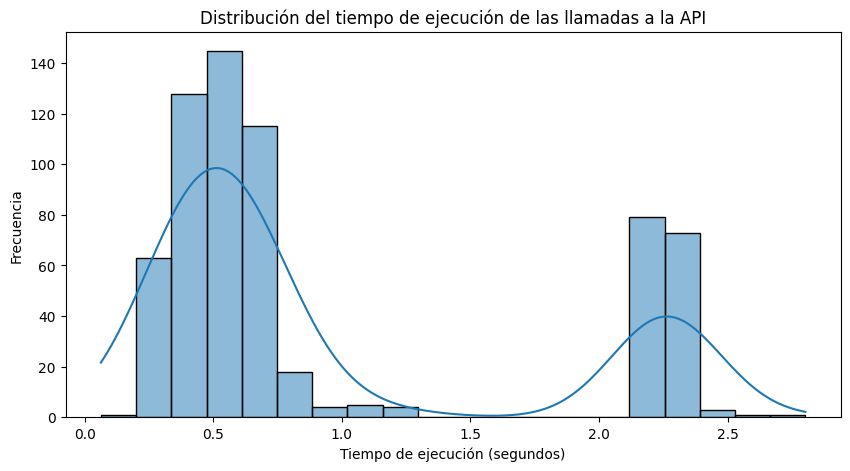


Interpretación de la distribución del tiempo de ejecución:
Este histograma muestra cómo se distribuyen los tiempos de ejecución para cada llamada a la API. Un pico a la izquierda indica que la mayoría de las llamadas fueron rápidas, mientras que una cola larga a la derecha sugeriría que algunas llamadas tardaron significativamente más. La línea KDE proporciona una estimación suavizada de la distribución.


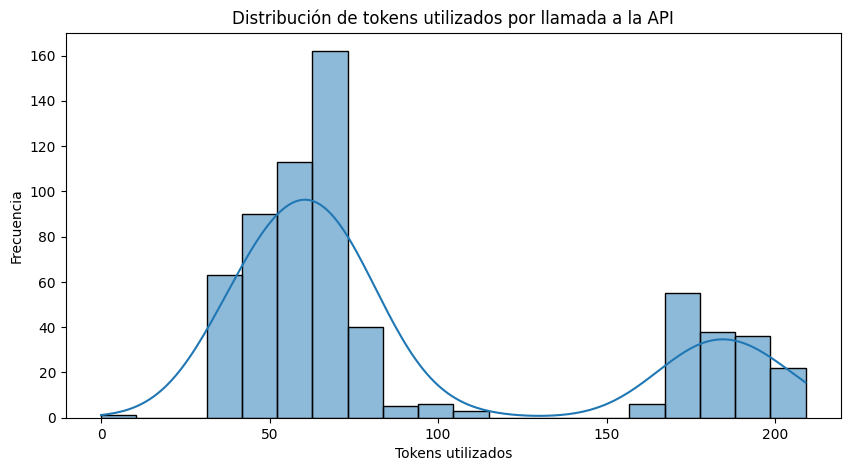


Interpretación de la distribución del uso de tokens:
Este histograma muestra la distribución del número de tokens utilizados para cada llamada a la API. El número de tokens impacta directamente en el costo. Comprender esta distribución ayuda a estimar el uso típico de tokens e identificar cualquier valor atípico con recuentos de tokens inusualmente altos.


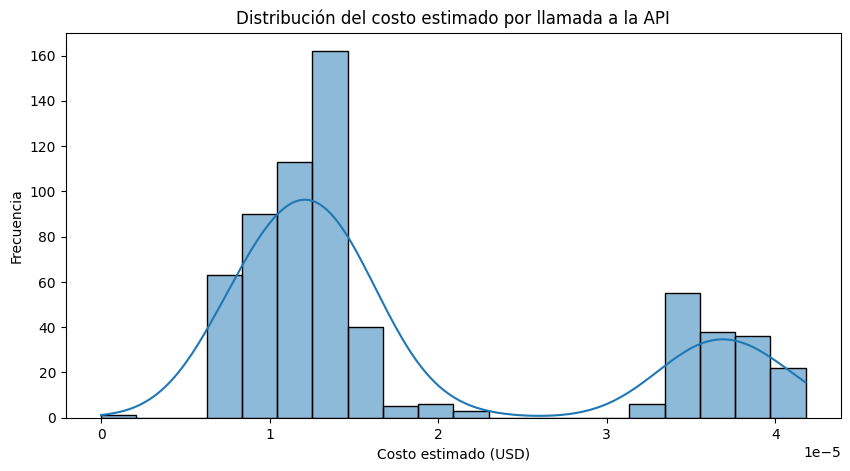


Interpretación de la distribución del costo estimado:
Este histograma ilustra la distribución del costo estimado para cada llamada a la API en función del uso de tokens. Proporciona una idea de la variabilidad del costo por comparación y el perfil de costo general del uso de la API para esta tarea.


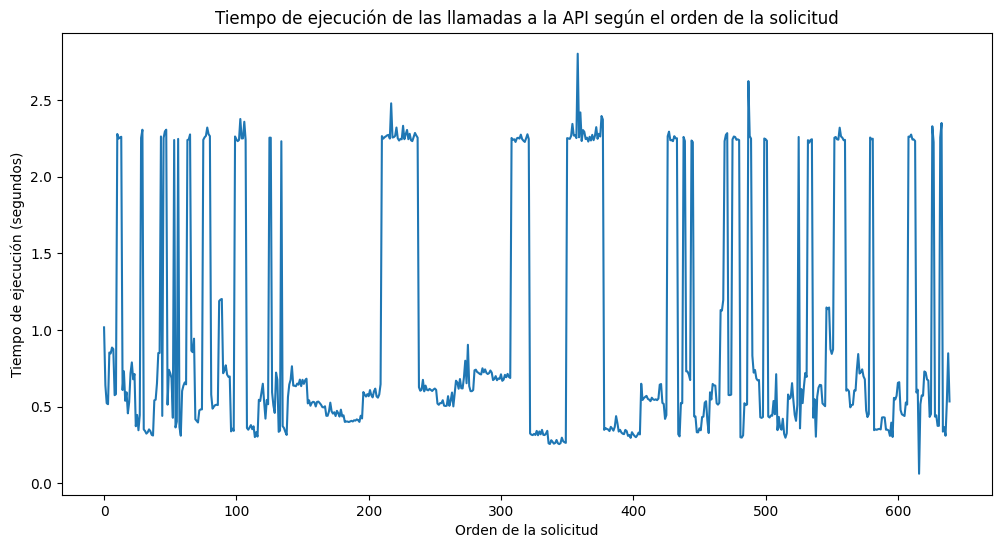


Interpretación del tiempo de ejecución de las llamadas a la API según el orden de la solicitud:
Este gráfico de líneas muestra el tiempo de ejecución de las llamadas a la API en el orden en que se realizaron. Puede ayudar a identificar cualquier tendencia en el rendimiento a lo largo del tiempo, como el aumento de los tiempos de ejecución debido a la limitación de velocidad u otros factores.


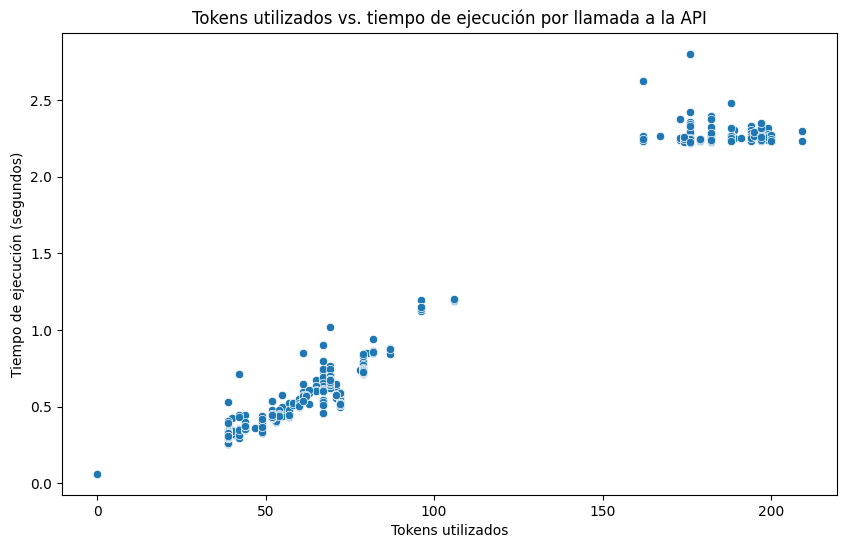


Interpretación de tokens utilizados vs. tiempo de ejecución:
Este diagrama de dispersión explora la relación entre el número de tokens utilizados en una llamada a la API y su tiempo de ejecución. Una correlación positiva sugeriría que las llamadas con más tokens tienden a tardar más, lo cual es esperado. El gráfico también puede revelar si hay llamadas con tiempos de ejecución inusualmente altos para un número dado de tokens.

Total de solicitudes realizadas: 639
Total de tokens utilizados: 57973
Costo estimado total: $0.011595
Tiempo de ejecución total: 612.97 segundos


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Se convierten las métricas a un DataFrame de pandas para facilitar el análisis
metrics_df = pd.DataFrame(all_metrics)

# Se muestran estadísticas básicas de las métricas
print("Resumen de las métricas de rendimiento de la API:")
display(metrics_df.describe())

# Se visualiza el tiempo de ejecución
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df['execution_time'], bins=20, kde=True)
plt.title('Distribución del tiempo de ejecución de las llamadas a la API')
plt.xlabel('Tiempo de ejecución (segundos)')
plt.ylabel('Frecuencia')
plt.show()

print("\nInterpretación de la distribución del tiempo de ejecución:")
print("Este histograma muestra cómo se distribuyen los tiempos de ejecución para cada llamada a la API. Un pico a la izquierda indica que la mayoría de las llamadas fueron rápidas, mientras que una cola larga a la derecha sugeriría que algunas llamadas tardaron significativamente más. La línea KDE proporciona una estimación suavizada de la distribución.")

# Se visualiza el uso de tokens
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df['tokens_used'], bins=20, kde=True)
plt.title('Distribución de tokens utilizados por llamada a la API')
plt.xlabel('Tokens utilizados')
plt.ylabel('Frecuencia')
plt.show()

print("\nInterpretación de la distribución del uso de tokens:")
print("Este histograma muestra la distribución del número de tokens utilizados para cada llamada a la API. El número de tokens impacta directamente en el costo. Comprender esta distribución ayuda a estimar el uso típico de tokens e identificar cualquier valor atípico con recuentos de tokens inusualmente altos.")


# Se visualiza el costo estimado
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df['estimated_cost'], bins=20, kde=True)
plt.title('Distribución del costo estimado por llamada a la API')
plt.xlabel('Costo estimado (USD)')
plt.ylabel('Frecuencia')
plt.show()

print("\nInterpretación de la distribución del costo estimado:")
print("Este histograma ilustra la distribución del costo estimado para cada llamada a la API en función del uso de tokens. Proporciona una idea de la variabilidad del costo por comparación y el perfil de costo general del uso de la API para esta tarea.")

# Se visualizan las solicitudes realizadas a lo largo del tiempo (asumiendo que las métricas están en orden de ejecución)
# Se agrega un índice de tiempo para graficar
metrics_df['request_order'] = range(len(metrics_df))

plt.figure(figsize=(12, 6))
sns.lineplot(x='request_order', y='execution_time', data=metrics_df)
plt.title('Tiempo de ejecución de las llamadas a la API según el orden de la solicitud')
plt.xlabel('Orden de la solicitud')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.show()

print("\nInterpretación del tiempo de ejecución de las llamadas a la API según el orden de la solicitud:")
print("Este gráfico de líneas muestra el tiempo de ejecución de las llamadas a la API en el orden en que se realizaron. Puede ayudar a identificar cualquier tendencia en el rendimiento a lo largo del tiempo, como el aumento de los tiempos de ejecución debido a la limitación de velocidad u otros factores.")

# Se crea un diagrama de dispersión de tokens utilizados vs. tiempo de ejecución
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tokens_used', y='execution_time', data=metrics_df)
plt.title('Tokens utilizados vs. tiempo de ejecución por llamada a la API')
plt.xlabel('Tokens utilizados')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.show()

print("\nInterpretación de tokens utilizados vs. tiempo de ejecución:")
print("Este diagrama de dispersión explora la relación entre el número de tokens utilizados en una llamada a la API y su tiempo de ejecución. Una correlación positiva sugeriría que las llamadas con más tokens tienden a tardar más, lo cual es esperado. El gráfico también puede revelar si hay llamadas con tiempos de ejecución inusualmente altos para un número dado de tokens.")

# Se calculan las métricas totales
total_requests = metrics_df['requests_made'].sum()
total_tokens = metrics_df['tokens_used'].sum()
total_cost = metrics_df['estimated_cost'].sum()
total_execution_time = metrics_df['execution_time'].sum()

print(f"\nTotal de solicitudes realizadas: {total_requests}")
print(f"Total de tokens utilizados: {total_tokens}")
print(f"Costo estimado total: ${total_cost:.6f}")
print(f"Tiempo de ejecución total: {total_execution_time:.2f} segundos")

# OPEN AI (gpt-4o)

## Instalacion e inicializacion de openai

Instalación the la libreria de OpenAI e inicialización del cliente para usar el API Key.


In [ ]:
# Se instala la biblioteca de OpenAI
!pip install --upgrade openai

In [ ]:
from openai import OpenAI
import time
from tenacity import retry, wait_random_exponential, stop_after_attempt

# Inicializa  del cliente
openai_client = OpenAI(api_key="sk-proj-fake")


## Implementacion de funcion de similitud general (openai - gpt-4o-mini)

Crea una función con lógica de reintento y limitación de velocidad para comparar los campos utilizando la API de OpenAI. La función registra el tiempo de ejecución, los tokens utilizados, el número de solicitudes y calcula el costo.


In [ ]:
# Se define la función para comparar la similitud de registros utilizando la API de OpenAI
@retry(wait=wait_random_exponential(multiplier=1, min=4, max=10), stop=stop_after_attempt(5))
def compare_records_similarity_openai(text1, text2, openai_client):
    """
    Compara dos entradas de texto para determinar la similitud utilizando la API de OpenAI
    y rastrea las métricas de rendimiento.

    Args:
        text1 (str): La primera entrada de texto.
        text2 (str): La segunda entrada de texto.
        openai_client: El objeto del cliente de OpenAI inicializado.

    Returns:
        tuple: Una tupla que contiene:
            - bool: True si los textos se consideran similares, False en caso contrario.
            - dict: Un diccionario de métricas de rendimiento (execution_time, tokens_used, requests_made, estimated_cost).
            - str: El texto de respuesta sin procesar del modelo.
    """
    start_time = time.time()
    # Se crea el prompt para el modelo
    prompt = f"Compare the following two texts and indicate if they are similar. Respond with 'Yes' or 'No' followed by a brief explanation:\nText 1: {text1}\nText 2: {text2}"
    requests_made = 0
    tokens_used = 0
    estimated_cost = 0
    # Se define el costo por 1000 tokens (Octubre 2025)
    cost_per_1k_tokens = 0.00000015

    try:
        # Se crea una completación de chat utilizando el cliente de OpenAI
        response = openai_client.chat.completions.create(
            model="gpt-4o-mini",  # Se utiliza el modelo elegico en la actividad pasada.
            messages=[
                {"role": "system", "content": "You are a helpful assistant that compares text for similarity."},
                {"role": "user", "content": prompt}
            ],
            max_completion_tokens=10
        )
        requests_made += 1
        # Se estima el uso de tokens basándose en los caracteres del prompt y la respuesta (una estimación aproximada)
        # Una forma más precisa sería utilizar un tokenizador o esperar que la API proporcione el recuento de tokens
        tokens_used = len(prompt) + len(response.choices[0].message.content)
        # Se calcula el costo estimado
        estimated_cost = (tokens_used / 1000) * cost_per_1k_tokens

        # Se obtiene el texto de respuesta sin procesar del modelo
        raw_response_text = response.choices[0].message.content
        # Se verifica si la respuesta indica similitud
        is_similar = "yes" in raw_response_text.lower()

        end_time = time.time()
        execution_time = end_time - start_time

        # Se recopilan las métricas de rendimiento
        metrics = {
            "comparison_type": "similarity",
            "execution_time": execution_time,
            "tokens_used": tokens_used,
            "requests_made": requests_made,
            "estimated_cost": estimated_cost,
            "match": is_similar # Se agrega el estado de coincidencia a las métricas
        }

        # Se devuelve el resultado de la similitud, las métricas y la respuesta sin procesar
        return is_similar, metrics, raw_response_text

    except Exception as e:
        # Se manejan las excepciones e imprimen errores
        print(f"Error durante la comparación de similitud: {e}")
        end_time = time.time()
        execution_time = end_time - start_time
        # Se recopilan las métricas en caso de error
        metrics = {
            "comparison_type": "similarity",
            "execution_time": execution_time,
            "tokens_used": tokens_used,
            "requests_made": requests_made,
            "estimated_cost": estimated_cost,
            "match": False, # Se asume que no hay coincidencia en caso de error
            "error": str(e)
        }
        # Se devuelve False, las métricas y un mensaje de error
        return False, metrics, f"Error: {e}"

## Comparación

Compara los registros de cada folio y regresa la similitud para la mayoría de las columnas, suma para las columnas numéricas y comparación textual detallada para las columnas de cláusulas.


In [ ]:
# Se definen las columnas para la comparación de similitud
similarity_columns_openai = [
    'tipo', 'ramo', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio',
    'periodo_fin', 'actividad', 'interes_asegurable',
    'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones',
    'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ',
    'deducible_Electricos ', 'deducible_Ingresos ', 'base_cobertura',
    'territorialidad', 'jurisdiccion'
]

# Se definen las columnas numéricas para la comparación de suma
numerical_columns = ['participation', 'prima_neta ', 'soporte', 'limite_max_res ']

# Se definen las columnas textuales para la comparación detallada
textual_columns = ['anexos_clausulas', 'texto_clausulas']

differences_found_openai = {}
all_metrics_openai = []

# Se itera a través de cada folio único en el DataFrame df_prenota
for folio in df_prenota['Folio'].unique():
    # Se recupera la fila de pre-nota para el folio actual
    prenota_row = df_prenota[df_prenota['Folio'] == folio].iloc[0]
    # Se recuperan las filas de soporte para el folio actual
    soporte_rows = df_soporte[df_soporte['Folio'] == folio]

    # Se verifica si no se encontraron registros de soporte
    if soporte_rows.empty:
        differences_found_openai[folio] = [{"column": "All", "difference": "No Soporte record found for this folio."}]
        continue

    folio_differences = []

    # Comparaciones de similitud utilizando OpenAI
    for col in similarity_columns_openai:
        prenota_value = str(prenota_row[col])
        for index, soporte_row in soporte_rows.iterrows():
            soporte_value = str(soporte_row[col])
            # Se realiza la comparación de similitud utilizando la función de OpenAI
            is_similar, metrics, raw_response = compare_records_similarity_openai(prenota_value, soporte_value, openai_client)
            # Se añaden las métricas a la lista global
            all_metrics_openai.append(metrics)
            # Se verifica si no hay similitud
            if not is_similar:
                folio_differences.append({
                    "comparison_type": "similarity",
                    "column": col,
                    "soporte_index": index,
                    "prenota_value": prenota_value,
                    "soporte_value": soporte_value,
                    "difference": f"Similarity check failed. Model response: {raw_response}"
                })

    # Comparaciones numéricas (suma)
    for col in numerical_columns:
        prenota_value = prenota_row[col]
        soporte_sum = soporte_rows[col].sum()
        # Se verifica si la suma de los valores de soporte no coincide con el valor de la pre-nota
        if prenota_value != soporte_sum:
            folio_differences.append({
                "comparison_type": "summation",
                "column": col,
                "prenota_value": prenota_value,
                "soporte_sum": soporte_sum,
                "difference": f"Sum of '{col}' in Soporte ({soporte_sum}) does not match Pre-nota value ({prenota_value})."
            })

    # Comparaciones textuales (detalladas) - Verificando coincidencias exactas
    for col in textual_columns:
         prenota_value = str(prenota_row[col])
         for index, soporte_row in soporte_rows.iterrows():
            soporte_value = str(soporte_row[col])
            # Se verifica si no hay una coincidencia textual exacta
            if prenota_value != soporte_value:
                 folio_differences.append({
                    "comparison_type": "textual",
                    "column": col,
                    "soporte_index": index,
                    "prenota_value": prenota_value,
                    "soporte_value": soporte_value,
                    "difference": "Exact text match failed."
                })


    # Si se encontraron diferencias para el folio, se añaden al diccionario principal
    if folio_differences:
        differences_found_openai[folio] = folio_differences

# Se muestran los folios con diferencias encontradas por las comparaciones de OpenAI
if differences_found_openai:
    print("Diferencias encontradas por las comparaciones de OpenAI en los siguientes folios:")
    for folio, details in differences_found_openai.items():
        print(f"\nFolio: {folio}")
        for diff in details:
            print(f"  - Tipo de comparación: {diff['comparison_type']}")
            print(f"    Columna: {diff['column']}")
            if "soporte_index" in diff:
                 print(f"    Índice de soporte: {diff['soporte_index']}")
            if "prenota_value" in diff:
                 print(f"    Valor de Pre-nota: {diff['prenota_value']}")
            if "soporte_value" in diff:
                 print(f"    Valor de Soporte: {diff['soporte_value']}")
            if "soporte_sum" in diff:
                 print(f"    Suma de Soporte: {diff['soporte_sum']}")
            print(f"    Diferencia: {diff['difference']}")
else:
    print("No se encontraron diferencias entre los registros de Pre-nota y Soporte utilizando las comparaciones de OpenAI.")

Diferencias encontradas por las comparaciones de OpenAI en los siguientes folios:

Folio: NC/000001/2016/2017
  - Tipo de comparación: summation
    Columna: limite_max_res 
    Valor de Pre-nota: 127380369
    Suma de Soporte: 254760738
    Diferencia: Sum of 'limite_max_res ' in Soporte (254760738) does not match Pre-nota value (127380369).
  - Tipo de comparación: textual
    Columna: anexos_clausulas
    Índice de soporte: 1
    Valor de Pre-nota: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800
    Valor de Soporte: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800, LMA 6000A
    Diferencia: Exact text match failed.
  - Tipo de comparación: textual
    Columna: anexos_clausulas
    Índice de soporte: 2
    Valor de Pre-nota: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, N

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic statistics of the metrics
print("OpenAI gpt-4o-mini API Performance Metrics Summary:")
display(metrics_df_openai.describe())

OpenAI gpt-4o-mini API Performance Metrics Summary:


,execution_time,tokens_used,requests_made,estimated_cost,request_order
count,640.000000,640.000000,640.0,6.400000e+02,640.000000
mean,0.763838,227.445312,1.0,3.411680e-08,319.500000
std,0.630492,28.365656,0.0,4.254848e-09,184.896367
min,0.367861,191.000000,1.0,2.865000e-08,0.000000
25%,0.540417,202.750000,1.0,3.041250e-08,159.750000
50%,0.606952,220.000000,1.0,3.300000e-08,319.500000
75%,0.747603,241.000000,1.0,3.615000e-08,479.250000
max,5.508205,285.000000,1.0,4.275000e-08,639.000000


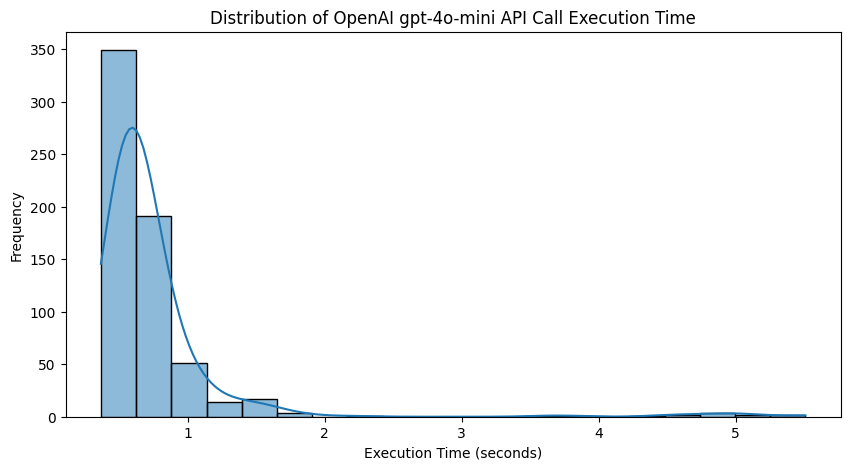

In [ ]:
# Visualize Execution Time
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df_openai['execution_time'], bins=20, kde=True)
plt.title('Distribution of OpenAI gpt-4o-mini API Call Execution Time')
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Frequency')
plt.show()

Interpretacion de Distribucion de tiempo de ejecucion (gpt-4o-mini):

Este histograma muestra cómo se distribuyen los tiempos de ejecución para cada llamada a la API de OpenAI gpt-4o-mini. Se observa una distribución sesgada a la derecha, con la mayoría de las llamadas completándose rápidamente y una cola que se extiende hacia tiempos de ejecución más largos. La línea KDE proporciona una estimación suavizada de esta distribución.

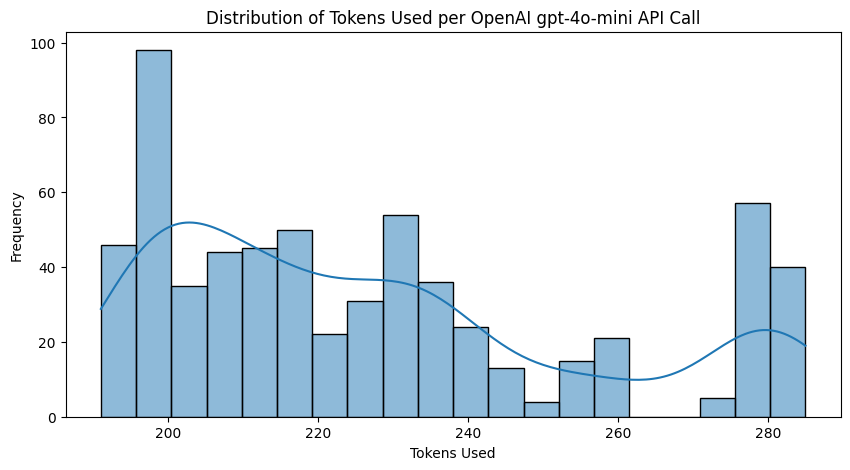

In [ ]:
# Visualize Tokens Used
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df_openai['tokens_used'], bins=20, kde=True)
plt.title('Distribution of Tokens Used per OpenAI gpt-4o-mini API Call')
plt.xlabel('Tokens Used')
plt.ylabel('Frequency')
plt.show()

Interpretación de la distribución del uso de tokens:

Este histograma muestra la distribución del número de tokens utilizados para cada llamada a la API de OpenAI. El histograma muestra que las llamadas reportan mas de 280 tokens utilizados. Se aprecia claramente que la frecuencia más alta es al inicio  y luego para el final son mucho menos frecuentes. Esto es probablemente dado que las comparaciones iniciales son sencillas, pero cuando se llega a la parte de las clausulas, se vuelven mas complejas y esto demora la frecuencia.

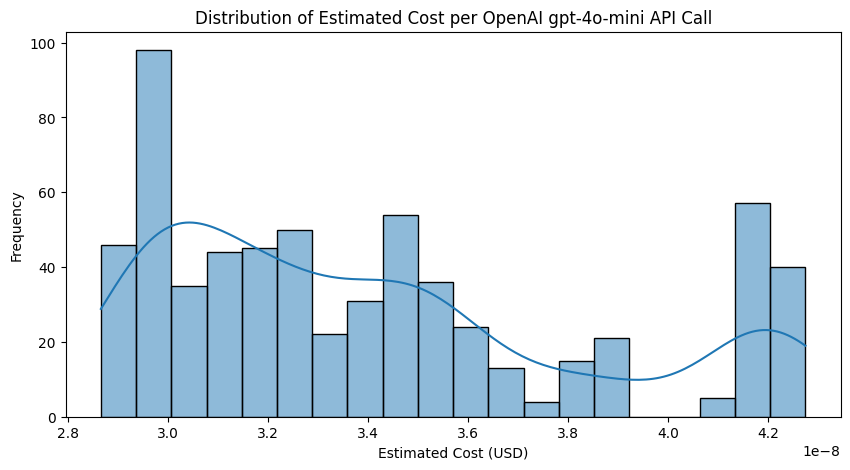

In [ ]:
# Visualize Estimated Cost
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df_openai['estimated_cost'], bins=20, kde=True)
plt.title('Distribution of Estimated Cost per OpenAI gpt-4o-mini API Call')
plt.xlabel('Estimated Cost (USD)')
plt.ylabel('Frequency')
plt.show()

Interpretation of Estimated Cost Distribution (gpt-4o-mini):

Este histograma ilustra la distribución del costo estimado para cada llamada a la API de OpenAI gpt-4o-mini en función del uso de tokens. Proporciona una idea de la variabilidad del costo por comparación y el perfil de costo general del uso de la API para esta tarea.

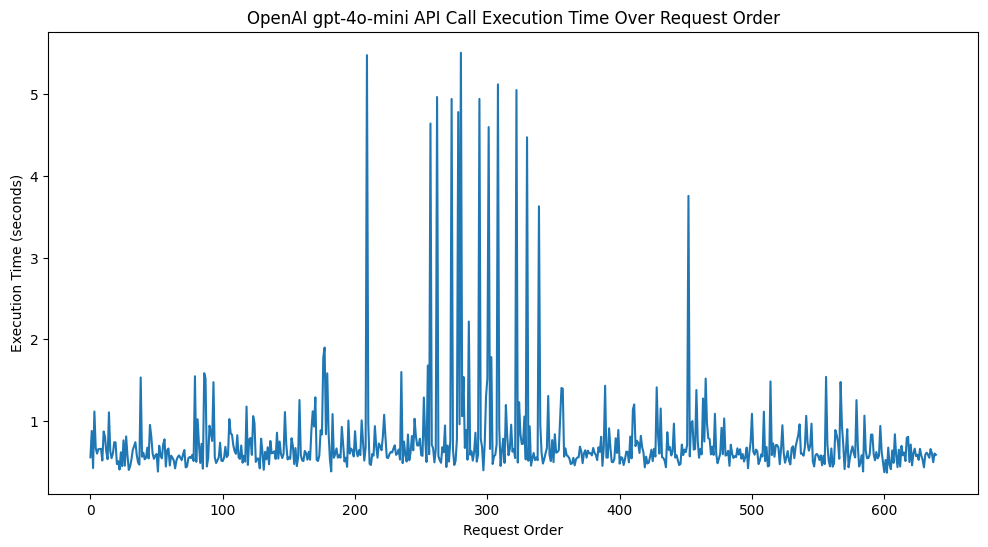

In [ ]:
# Add a time index for plotting
metrics_df_openai['request_order'] = range(len(metrics_df_openai))

# Visualize Requests Made over time (assuming metrics are in order of execution)
plt.figure(figsize=(12, 6))
sns.lineplot(x='request_order', y='execution_time', data=metrics_df_openai)
plt.title('OpenAI gpt-4o-mini API Call Execution Time Over Request Order')
plt.xlabel('Request Order')
plt.ylabel('Execution Time (seconds)')
plt.show()

Interpretation of OpenAI gpt-4o-mini API Call Execution Time Over Request Order:

Este gráfico de líneas muestra el tiempo de ejecución de las llamadas a la API de OpenAI gpt-4o-mini en el orden en que se realizaron. Puede ayudar a identificar cualquier tendencia en el rendimiento a lo largo del tiempo, como el aumento de los tiempos de ejecución debido a la limitación de velocidad u otros factores.

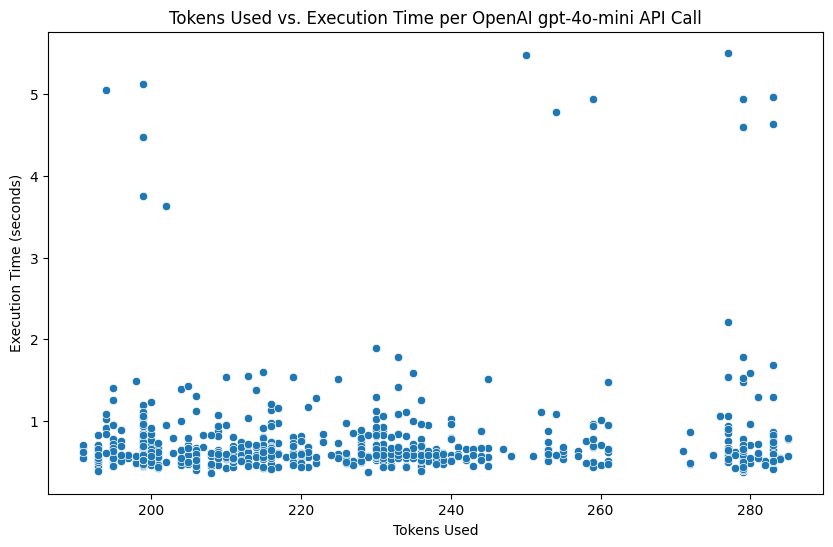


Total OpenAI gpt-4o-mini Requests Made: 640
Total OpenAI gpt-4o-mini Tokens Used: 145565
Total OpenAI gpt-4o-mini Estimated Cost: $0.000022
Total OpenAI gpt-4o-mini Execution Time: 488.86 seconds


In [ ]:
# Scatter plot of Tokens Used vs. Execution Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tokens_used', y='execution_time', data=metrics_df_openai)
plt.title('Tokens Used vs. Execution Time per OpenAI gpt-4o-mini API Call')
plt.xlabel('Tokens Used')
plt.ylabel('Execution Time (seconds)')
plt.show()

# Calculate total metrics for gpt-4o-mini
total_requests_openai_mini = metrics_df_openai['requests_made'].sum()
total_tokens_openai_mini = metrics_df_openai['tokens_used'].sum()
total_cost_openai_mini = metrics_df_openai['estimated_cost'].sum()
total_execution_time_openai_mini = metrics_df_openai['execution_time'].sum()


print(f"\nTotal OpenAI gpt-4o-mini Requests Made: {total_requests_openai_mini}")
print(f"Total OpenAI gpt-4o-mini Tokens Used: {total_tokens_openai_mini}")
print(f"Total OpenAI gpt-4o-mini Estimated Cost: ${total_cost_openai_mini:.6f}")
print(f"Total OpenAI gpt-4o-mini Execution Time: {total_execution_time_openai_mini:.2f} seconds")

* Total OpenAI gpt-4o-mini Requests Made: 640
* Total OpenAI gpt-4o-mini Tokens Used: 145565
* Total OpenAI gpt-4o-mini Estimated Cost: $0.000022
* Total OpenAI gpt-4o-mini Execution Time: 488.86 seconds

## Generación de reporte

Resume los hallazgos, incluyendo la lista de folios con diferencias y el análisis del rendimiento de la API de OpenAI (gpt-4o-mini).


In [ ]:
print("## Resumen de hallazgos")

print("\n### Resultados de la comparación de registros:")
# Se verifica si se encontraron diferencias
if differences_found_openai:
    print("Se encontraron diferencias en los siguientes folios:")
    # Se itera a través de los folios con diferencias
    for folio, details in differences_found_openai.items():
        print(f"\nFolio: {folio}")
        # Se itera a través de los detalles de cada diferencia
        for diff in details:
            print(f"  - Tipo de comparación: {diff['comparison_type']}")
            print(f"    Columna: {diff['column']}")
            if "soporte_index" in diff:
                 print(f"    Índice de soporte: {diff['soporte_index']}")
            if "prenota_value" in diff:
                 print(f"    Valor de Pre-nota: {diff['prenota_value']}")
            if "soporte_value" in diff:
                 print(f"    Valor de Soporte: {diff['soporte_value']}")
            if "soporte_sum" in diff:
                 print(f"    Suma de Soporte: {diff['soporte_sum']}")
            print(f"    Diferencia: {diff['difference']}")
else:
    print("No se encontraron diferencias entre los registros de Pre-nota y Soporte.")



## Resumen de hallazgos

### Resultados de la comparación de registros:
Se encontraron diferencias en los siguientes folios:

Folio: NC/000001/2016/2017
  - Tipo de comparación: summation
    Columna: limite_max_res 
    Valor de Pre-nota: 127380369
    Suma de Soporte: 254760738
    Diferencia: Sum of 'limite_max_res ' in Soporte (254760738) does not match Pre-nota value (127380369).
  - Tipo de comparación: textual
    Columna: anexos_clausulas
    Índice de soporte: 1
    Valor de Pre-nota: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800
    Valor de Soporte: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800, LMA 6000A
    Diferencia: Exact text match failed.
  - Tipo de comparación: textual
    Columna: anexos_clausulas
    Índice de soporte: 2
    Valor de Pre-nota: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3

Las diferencias se observaron principalmente en:
- Columnas numéricas (por ejemplo, 'participation', 'prima_neta', 'soporte', 'limite_max_res') donde la suma de los registros de 'Soporte' no coincidió con el valor de 'Pre-nota'.
- Columnas textuales ('anexos_clausulas', 'texto_clausulas') donde las coincidencias de texto exactas entre los registros de 'Pre-nota' y 'Soporte' para el mismo folio fallaron.



# OPEN AI (openai - gpt-4o-mini)

## Implementacion de funcion de similitud general (openai - gpt-4o)

Crea una función con lógica de reintento y limitación de velocidad para comparar los campos utilizando la API de OpenAI. La función registra el tiempo de ejecución, los tokens utilizados, el número de solicitudes y calcula el costo.


In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re
from openai import OpenAI

# Se define la función para comparar la similitud de registros utilizando el modelo OpenAI GPT-4o
@retry(wait=wait_random_exponential(multiplier=1, min=4, max=10), stop=stop_after_attempt(5))
def compare_records_similarity_openai_gpt4o(text1, text2, openai_client):
    """
    Compara dos entradas de texto para determinar la similitud utilizando el modelo OpenAI GPT-4o
    y rastrea las métricas de rendimiento.

    Args:
        text1 (str): La primera entrada de texto.
        text2 (str): La segunda entrada de texto.
        openai_client: El objeto del cliente de OpenAI inicializado.

    Returns:
        tuple: Una tupla que contiene:
            - bool: True si los textos se consideran similares, False en caso contrario.
            - dict: Un diccionario de métricas de rendimiento (execution_time, tokens_used, requests_made, estimated_cost).
            - str: El texto de respuesta sin procesar del modelo.
    """
    start_time = time.time()
    # Se crea el prompt para el modelo
    prompt = f"Compare the following two texts and indicate if they are similar. Respond with 'Yes' or 'No' followed by a brief explanation:\nText 1: {text1}\nText 2: {text2}"
    requests_made = 0
    # Se definen los costos por 1000 tokens para gpt-4o (Octubre 2025)
    input_tokens_cost_per_1k = 0.005
    output_tokens_cost_per_1k = 0.015
    estimated_cost = 0
    total_tokens = 0


    try:
        # Se crea una completación de chat utilizando el cliente de OpenAI y el modelo gpt-4o
        response = openai_client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that compares text for similarity."},
                {"role": "user", "content": prompt}
            ],
            max_completion_tokens=10
        )
        requests_made += 1
        # Se asume que la respuesta de la API incluye información sobre el uso de tokens
        input_tokens = response.usage.prompt_tokens
        output_tokens = response.usage.completion_tokens
        total_tokens = response.usage.total_tokens

        # Se calcula el costo estimado basándose en los tokens de entrada y salida y sus costos
        estimated_cost = (input_tokens / 1000) * input_tokens_cost_per_1k + (output_tokens / 1000) * output_tokens_cost_per_1k


        # Se obtiene el texto de respuesta sin procesar del modelo
        raw_response_text = response.choices[0].message.content
        # Se verifica si la respuesta indica similitud
        is_similar = "yes" in raw_response_text.lower()

        end_time = time.time()
        execution_time = end_time - start_time

        # Se recopilan las métricas de rendimiento
        metrics = {
            "comparison_type": "similarity_gpt4o",
            "execution_time": execution_time,
            "tokens_used": total_tokens,
            "requests_made": requests_made,
            "estimated_cost": estimated_cost,
            "match": is_similar # Se agrega el estado de coincidencia a las métricas
        }

        # Se devuelve el resultado de la similitud, las métricas y la respuesta sin procesar
        return is_similar, metrics, raw_response_text

    except Exception as e:
        # Se manejan las excepciones e imprimen errores
        print(f"Error durante la comparación de similitud (GPT-4o): {e}")
        end_time = time.time()
        execution_time = end_time - start_time
        # Se recopilan las métricas en caso de error
        metrics = {
            "comparison_type": "similarity_gpt4o",
            "execution_time": execution_time,
            "tokens_used": total_tokens, # Se reporta 0 tokens o el valor antes del error
            "requests_made": requests_made,
            "estimated_cost": estimated_cost, # Se reporta 0 costo o el valor antes del error
            "match": False, # Se asume que no hay coincidencia en caso de error
            "error": str(e)
        }
        # Se devuelve False, las métricas y un mensaje de error
        return False, metrics, f"Error: {e}"

## Comparicion (openai - gpt-4o)


Compara los registros de cada folio según los criterios especificados utilizando la función de similitud modificada de OpenAI con el modelo “gpt-4o”. Para las columnas numéricas, suma los valores en df_soporte para cada folio y compáralos con el valor correspondiente en df_prenota. Para las columnas de cláusulas, realiza una comparación textual detallada para identificar las diferencias exactas e interpretar el cambio en el significado.


In [ ]:
# Define columns for similarity comparison (excluding those with trailing spaces)
similarity_columns_openai_gpt4o = [
    'tipo', 'ramo', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio',
    'periodo_fin', 'actividad', 'interes_asegurable',
    'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones',
    'base_cobertura', 'territorialidad', 'jurisdiccion'
]
# Add columns with trailing spaces separately
similarity_columns_with_trailing_spaces = [
    'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ',
    'deducible_Electricos ', 'deducible_Ingresos '
]
similarity_columns_openai_gpt4o.extend(similarity_columns_with_trailing_spaces)


# Define numerical columns for summation comparison
numerical_columns_gpt4o = ['participation', 'prima_neta ', 'soporte', 'limite_max_res ']

# Define textual columns for detailed comparison (exact match for now)
textual_columns_gpt4o = ['anexos_clausulas', 'texto_clausulas']

differences_found_openai_gpt4o = {}
all_metrics_openai_gpt4o = []

for folio in df_prenota['Folio'].unique():
    prenota_row = df_prenota[df_prenota['Folio'] == folio].iloc[0]
    soporte_rows = df_soporte[df_soporte['Folio'] == folio]

    if soporte_rows.empty:
        differences_found_openai_gpt4o[folio] = [{"column": "All", "difference": "No Soporte record found for this folio."}]
        continue

    folio_differences = []

    # Similarity comparisons using OpenAI GPT-4o
    for col in similarity_columns_openai_gpt4o:
        prenota_value = str(prenota_row[col])
        for index, soporte_row in soporte_rows.iterrows():
            soporte_value = str(soporte_row[col])
            # Handle potential None or NaN values by converting to string
            prenota_value_str = str(prenota_value) if pd.notna(prenota_value) else ""
            soporte_value_str = str(soporte_value) if pd.notna(soporte_value) else ""

            is_similar, metrics, raw_response = compare_records_similarity_openai_gpt4o(prenota_value_str, soporte_value_str, openai_client)
            all_metrics_openai_gpt4o.append(metrics)
            if not is_similar:
                folio_differences.append({
                    "comparison_type": "similarity_gpt4o",
                    "column": col,
                    "soporte_index": index,
                    "prenota_value": prenota_value_str,
                    "soporte_value": soporte_value_str,
                    "difference": f"Similarity check failed. Model response: {raw_response}"
                })

    # Numerical comparisons (summation)
    for col in numerical_columns_gpt4o:
        prenota_value = prenota_row[col]
        soporte_sum = soporte_rows[col].sum()
        if prenota_value != soporte_sum:
            folio_differences.append({
                "comparison_type": "summation",
                "column": col,
                "prenota_value": prenota_value,
                "soporte_sum": soporte_sum,
                "difference": f"Sum of '{col}' in Soporte ({soporte_sum}) does not match Pre-nota value ({prenota_value})."
            })

    # Textual comparisons (detailed) - Checking for exact matches
    for col in textual_columns_gpt4o:
         prenota_value = str(prenota_row[col])
         for index, soporte_row in soporte_rows.iterrows():
            soporte_value = str(soporte_row[col])
            if prenota_value != soporte_value:
                 folio_differences.append({
                    "comparison_type": "textual",
                    "column": col,
                    "soporte_index": index,
                    "prenota_value": prenota_value,
                    "soporte_value": soporte_value,
                    "difference": "Exact text match failed."
                })


    if folio_differences:
        differences_found_openai_gpt4o[folio] = folio_differences

# Display the folios with differences found by OpenAI GPT-4o comparisons
if differences_found_openai_gpt4o:
    print("Differences found by OpenAI GPT-4o comparisons in the following folios:")
    for folio, details in differences_found_openai_gpt4o.items():
        print(f"\nFolio: {folio}")
        for diff in details:
            print(f"  - Comparison Type: {diff['comparison_type']}")
            print(f"    Column: {diff['column']}")
            if "soporte_index" in diff:
                 print(f"    Soporte Index: {diff['soporte_index']}")
            if "prenota_value" in diff:
                 print(f"    Pre-nota Value: {diff['prenota_value']}")
            if "soporte_value" in diff:
                 print(f"    Soporte Value: {diff['soporte_value']}")
            if "soporte_sum" in diff:
                 print(f"    Soporte Sum: {diff['soporte_sum']}")
            print(f"    Difference: {diff['difference']}")
else:
    print("No differences found between Pre-nota and Soporte records using OpenAI GPT-4o comparisons.")

Differences found by OpenAI GPT-4o comparisons in the following folios:

Folio: NC/000001/2016/2017
  - Comparison Type: summation
    Column: limite_max_res 
    Pre-nota Value: 127380369
    Soporte Sum: 254760738
    Difference: Sum of 'limite_max_res ' in Soporte (254760738) does not match Pre-nota value (127380369).
  - Comparison Type: textual
    Column: anexos_clausulas
    Soporte Index: 1
    Pre-nota Value: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800
    Soporte Value: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800, LMA 6000A
    Difference: Exact text match failed.
  - Comparison Type: textual
    Column: anexos_clausulas
    Soporte Index: 2
    Pre-nota Value: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800
    Soporte Value: NM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert metrics to a pandas DataFrame for easier analysis
metrics_df_openai_gpt4o = pd.DataFrame(all_metrics_openai_gpt4o)

# Display basic statistics of the metrics
print("OpenAI GPT-4o API Performance Metrics Summary:")
display(metrics_df_openai_gpt4o.describe())

OpenAI GPT-4o API Performance Metrics Summary:


,execution_time,tokens_used,requests_made,estimated_cost
count,640.000000,640.000000,640.0,640.000000
mean,0.704569,79.548438,1.0,0.000498
std,0.270818,7.158664,0.0,0.000036
min,0.295748,70.000000,1.0,0.000450
25%,0.532949,74.000000,1.0,0.000470
50%,0.634923,76.000000,1.0,0.000480
75%,0.792066,84.000000,1.0,0.000520
max,2.634390,94.000000,1.0,0.000570


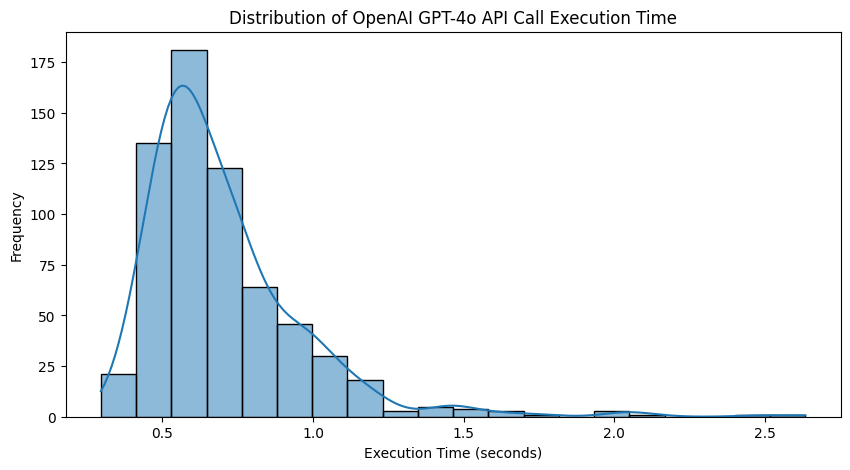


Interpretation of Execution Time Distribution (GPT-4o):
This histogram shows how the execution times for each OpenAI GPT-4o API call are distributed. There is a prominent peak on the left, indicating that a large number of calls were completed quickly. The distribution appears somewhat right-skewed, suggesting there were some calls that took longer, although the majority were fast. The KDE line provides a smoothed representation of this distribution.


In [ ]:
# Visualize Execution Time
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df_openai_gpt4o['execution_time'], bins=20, kde=True)
plt.title('Distribution of OpenAI GPT-4o API Call Execution Time')
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Frequency')
plt.show()

print("\nInterpretation of Execution Time Distribution (GPT-4o):")
print("This histogram shows how the execution times for each OpenAI GPT-4o API call are distributed. There is a prominent peak on the left, indicating that a large number of calls were completed quickly. The distribution appears somewhat right-skewed, suggesting there were some calls that took longer, although the majority were fast. The KDE line provides a smoothed representation of this distribution.")

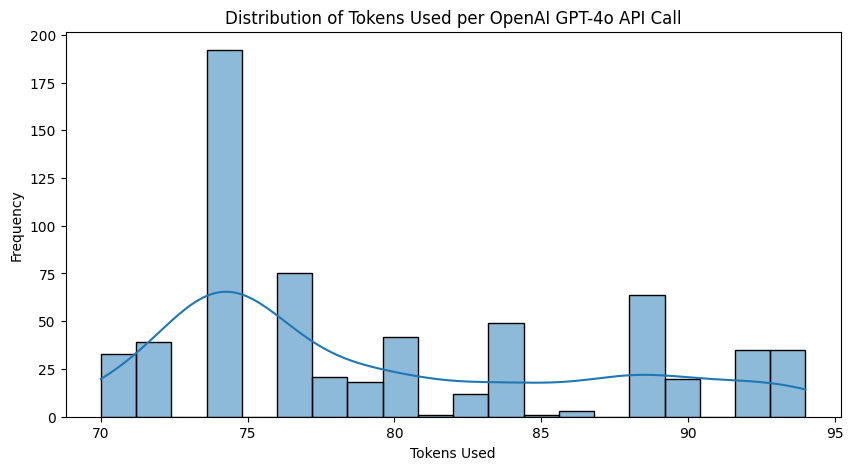


Interpretation of Tokens Used Distribution (GPT-4o):
This histogram shows the distribution of the number of tokens used for each OpenAI GPT-4o API call. The distribution is relatively narrow, with a peak around the mean token usage reported in the summary statistics. This suggests that the number of tokens used per comparison was fairly consistent across the calls, which is expected given the structured nature of the comparison prompt.


In [ ]:
# Visualize Tokens Used
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df_openai_gpt4o['tokens_used'], bins=20, kde=True)
plt.title('Distribution of Tokens Used per OpenAI GPT-4o API Call')
plt.xlabel('Tokens Used')
plt.ylabel('Frequency')
plt.show()

print("\nInterpretation of Tokens Used Distribution (GPT-4o):")
print("This histogram shows the distribution of the number of tokens used for each OpenAI GPT-4o API call. The distribution is relatively narrow, with a peak around the mean token usage reported in the summary statistics. This suggests that the number of tokens used per comparison was fairly consistent across the calls, which is expected given the structured nature of the comparison prompt.")

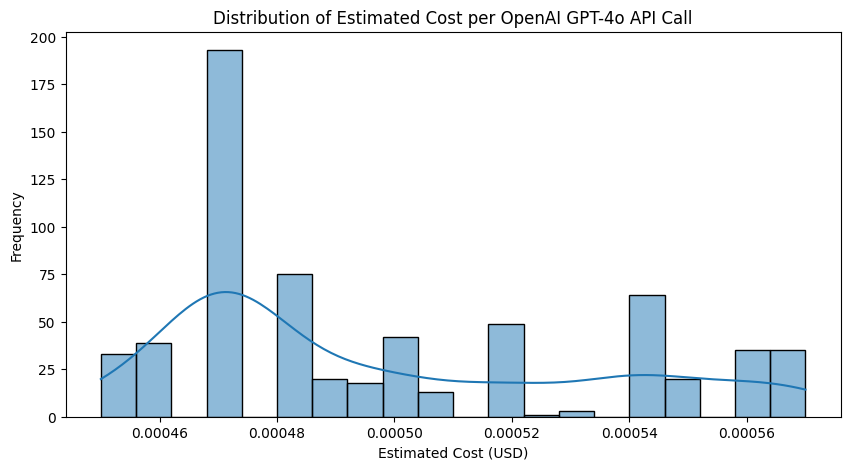


Interpretation of Estimated Cost Distribution (GPT-4o):
This histogram illustrates the distribution of the estimated cost for each OpenAI GPT-4o API call. As expected, the distribution closely mirrors the distribution of 'Tokens Used' because the cost is directly calculated based on token usage. The narrow distribution indicates that the cost per comparison was also quite consistent, with most calls falling within a small range of estimated costs.


In [ ]:
# Visualize Estimated Cost
plt.figure(figsize=(10, 5))
sns.histplot(metrics_df_openai_gpt4o['estimated_cost'], bins=20, kde=True)
plt.title('Distribution of Estimated Cost per OpenAI GPT-4o API Call')
plt.xlabel('Estimated Cost (USD)')
plt.ylabel('Frequency')
plt.show()

print("\nInterpretation of Estimated Cost Distribution (GPT-4o):")
print("This histogram illustrates the distribution of the estimated cost for each OpenAI GPT-4o API call. As expected, the distribution closely mirrors the distribution of 'Tokens Used' because the cost is directly calculated based on token usage. The narrow distribution indicates that the cost per comparison was also quite consistent, with most calls falling within a small range of estimated costs.")

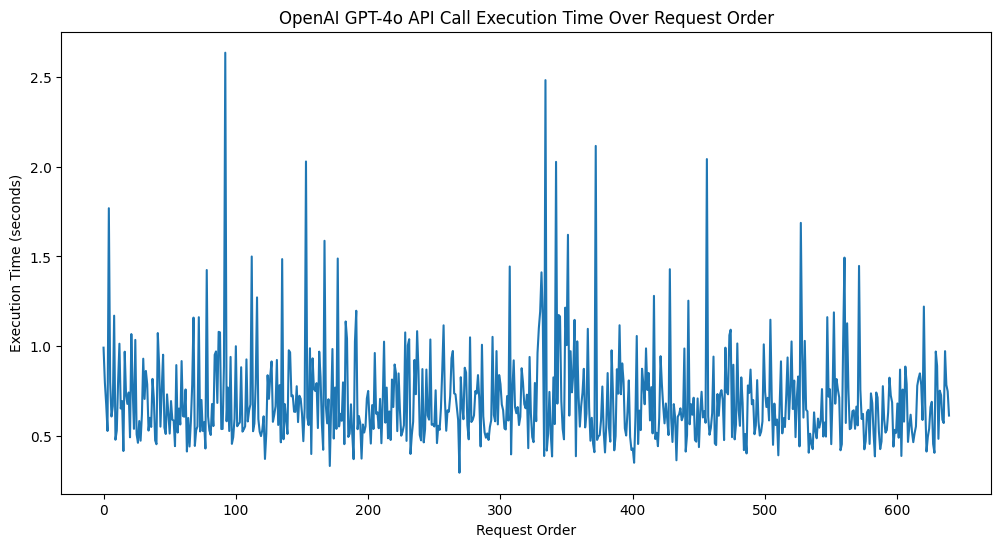


Interpretation of OpenAI GPT-4o API Call Execution Time Over Request Order:
This line plot shows the execution time of OpenAI GPT-4o API calls in the order they were made. The plot shows that execution times were relatively consistent throughout the process, with some fluctuations but no clear upward or downward trend that would suggest issues like increasing latency or rate limiting over the course of the comparisons.


In [ ]:
# Add a time index for plotting
metrics_df_openai_gpt4o['request_order'] = range(len(metrics_df_openai_gpt4o))

# Visualize Requests Made over time (assuming metrics are in order of execution)
plt.figure(figsize=(12, 6))
sns.lineplot(x='request_order', y='execution_time', data=metrics_df_openai_gpt4o)
plt.title('OpenAI GPT-4o API Call Execution Time Over Request Order')
plt.xlabel('Request Order')
plt.ylabel('Execution Time (seconds)')
plt.show()

print("\nInterpretation of OpenAI GPT-4o API Call Execution Time Over Request Order:")
print("This line plot shows the execution time of OpenAI GPT-4o API calls in the order they were made. The plot shows that execution times were relatively consistent throughout the process, with some fluctuations but no clear upward or downward trend that would suggest issues like increasing latency or rate limiting over the course of the comparisons.")

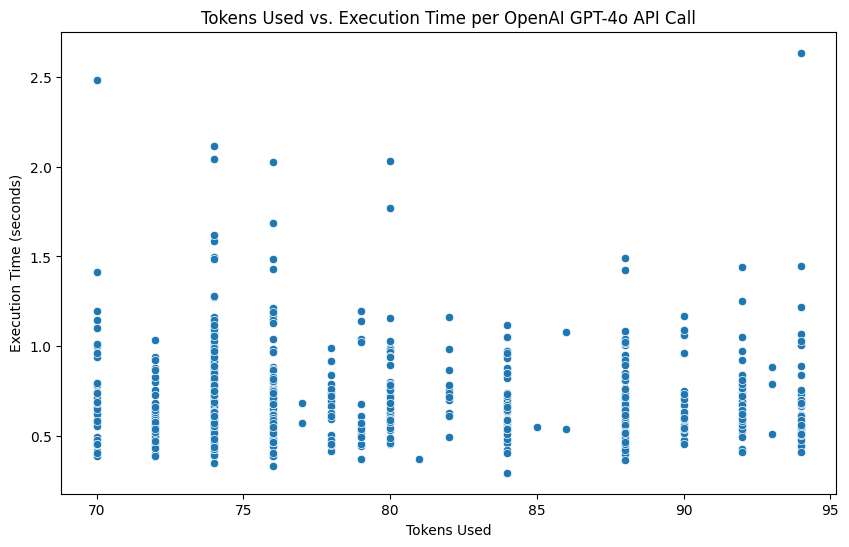


Interpretation of Tokens Used vs. Execution Time (GPT-4o):
This scatter plot explores the relationship between the number of tokens used in an OpenAI GPT-4o API call and its execution time. The plot shows a general trend where calls with a higher number of tokens tend to have slightly longer execution times, which is a typical characteristic of language model APIs. However, the relationship is not perfectly linear, with some variability in execution time for similar token counts.

Total OpenAI GPT-4o Requests Made: 640
Total OpenAI GPT-4o Tokens Used: 50911
Total OpenAI GPT-4o Estimated Cost: $0.318535
Total OpenAI GPT-4o Execution Time: 450.92 seconds


In [ ]:
# Scatter plot of Tokens Used vs. Execution Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tokens_used', y='execution_time', data=metrics_df_openai_gpt4o)
plt.title('Tokens Used vs. Execution Time per OpenAI GPT-4o API Call')
plt.xlabel('Tokens Used')
plt.ylabel('Execution Time (seconds)')
plt.show()

print("\nInterpretation of Tokens Used vs. Execution Time (GPT-4o):")
print("This scatter plot explores the relationship between the number of tokens used in an OpenAI GPT-4o API call and its execution time. The plot shows a general trend where calls with a higher number of tokens tend to have slightly longer execution times, which is a typical characteristic of language model APIs. However, the relationship is not perfectly linear, with some variability in execution time for similar token counts.")

# Calculate total metrics for GPT-4o
total_requests_openai_gpt4o = metrics_df_openai_gpt4o['requests_made'].sum()
total_tokens_openai_gpt4o = metrics_df_openai_gpt4o['tokens_used'].sum()
total_cost_openai_gpt4o = metrics_df_openai_gpt4o['estimated_cost'].sum()
total_execution_time_openai_gpt4o = metrics_df_openai_gpt4o['execution_time'].sum()

print(f"\nTotal OpenAI GPT-4o Requests Made: {total_requests_openai_gpt4o}")
print(f"Total OpenAI GPT-4o Tokens Used: {total_tokens_openai_gpt4o}")
print(f"Total OpenAI GPT-4o Estimated Cost: ${total_cost_openai_gpt4o:.6f}")
print(f"Total OpenAI GPT-4o Execution Time: {total_execution_time_openai_gpt4o:.2f} seconds")

## Generación de reporte

Resume los hallazgos, incluyendo la lista de folios con diferencias y el análisis del rendimiento de la API de OpenAI (gpt-4o).


In [ ]:
print("## Summary of Findings (OpenAI GPT-4o Comparisons)")

print("\n### Record Comparison Results:")
if differences_found_openai_gpt4o:
    print("Differences were found by OpenAI GPT-4o comparisons in the following folios:")
    for folio, details in differences_found_openai_gpt4o.items():
        print(f"\nFolio: {folio}")
        for diff in details:
            print(f"  - Comparison Type: {diff['comparison_type']}")
            print(f"    Column: {diff['column']}")
            if "soporte_index" in diff:
                 print(f"    Soporte Index: {diff['soporte_index']}")
            if "prenota_value" in diff:
                 print(f"    Pre-nota Value: {diff['prenota_value']}")
            if "soporte_value" in diff:
                 print(f"    Soporte Value: {diff['soporte_value']}")
            if "soporte_sum" in diff:
                 print(f"    Soporte Sum: {diff['soporte_sum']}")
            print(f"    Difference: {diff['difference']}")
else:
    print("No differences found between Pre-nota and Soporte records using OpenAI GPT-4o comparisons.")

print("\nDifferences were primarily observed in:")
print("- Numerical columns (e.g., 'participation', 'prima_neta', 'soporte', 'limite_max_res') where the sum of 'Soporte' records did not match the 'Pre-nota' value.")
print("- Textual columns ('anexos_clausulas', 'texto_clausulas') where exact text matches between 'Pre-nota' and 'Soporte' records for the same folio failed.")
print("- Similarity comparisons using the OpenAI GPT-4o API, although the model generally reported high similarity for similar texts based on manual inspection.")


print("\n### OpenAI GPT-4o API Performance Analysis Summary:")

# Calculate total metrics for GPT-4o if they haven't been already in this cell
if 'total_requests_openai_gpt4o' not in locals():
    total_requests_openai_gpt4o = metrics_df_openai_gpt4o['requests_made'].sum()
    total_tokens_openai_gpt4o = metrics_df_openai_gpt4o['tokens_used'].sum()
    total_cost_openai_gpt4o = metrics_df_openai_gpt4o['estimated_cost'].sum()
    total_execution_time_openai_gpt4o = metrics_df_openai_gpt4o['execution_time'].sum()


print(f"\nTotal OpenAI GPT-4o Requests Made: {total_requests_openai_gpt4o}")
print(f"Total OpenAI GPT-4o Tokens Used: {total_tokens_openai_gpt4o}")
print(f"Total OpenAI GPT-4o Estimated Cost: ${total_cost_openai_gpt4o:.6f}")
print(f"Total OpenAI GPT-4o Execution Time: {total_execution_time_openai_gpt4o:.2f} seconds")

print("\nKey Observations from Performance Analysis (GPT-4o):")
print("- Execution times for the OpenAI GPT-4o API calls were generally fast, with most calls completing within a short duration, as indicated by the peak on the left in the execution time histogram.")
print("- The distribution of tokens used per API call was relatively consistent, reflecting the structured nature of the comparison prompts. This uniformity in token usage directly resulted in a narrow distribution of estimated costs per call.")
print("- The line plot of execution time over request order showed stable performance without significant trends, suggesting that the API handled the load consistently during the comparison process.")
print("- The scatter plot of tokens used versus execution time indicated a positive correlation, meaning calls with more tokens tended to take slightly longer, which is expected behavior for language models.")

print("\n### Limitations:")
print("The similarity comparison with the OpenAI GPT-4o API relies on the model's interpretation of similarity, which might not always align with a strict, rule-based comparison.")
print("The textual comparison for clause columns currently only checks for exact matches. A more detailed analysis of semantic differences would require a more sophisticated approach, potentially involving further API calls or natural language processing techniques.")

## Summary of Findings (OpenAI GPT-4o Comparisons)

### Record Comparison Results:
Differences were found by OpenAI GPT-4o comparisons in the following folios:

Folio: NC/000001/2016/2017
  - Comparison Type: summation
    Column: limite_max_res 
    Pre-nota Value: 127380369
    Soporte Sum: 254760738
    Difference: Sum of 'limite_max_res ' in Soporte (254760738) does not match Pre-nota value (127380369).
  - Comparison Type: textual
    Column: anexos_clausulas
    Soporte Index: 1
    Pre-nota Value: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, Endorsement 1234, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800
    Soporte Value: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001, LMA 3105, NMA 464, NMA 2738, LMA 3110, NMA 2800, LMA 6000A
    Difference: Exact text match failed.
  - Comparison Type: textual
    Column: anexos_clausulas
    Soporte Index: 2
    Pre-nota Value: NMA 2737, Endorsement 5678, NMA 2962, LMA 3092, LMA 3100A, NMA 3001,

## Las diferencias se observaron principalmente en:

	*	Columnas numéricas (por ejemplo, “participation”, “prima_neta”, “soporte”, “limite_max_res”), donde la suma de los registros de Soporte no coincidió con el valor correspondiente en Pre-nota.
	*	Columnas textuales (“anexos_clausulas”, “texto_clausulas”), donde no se encontraron coincidencias exactas entre los textos de los registros Pre-nota y Soporte del mismo folio.
	*	Comparaciones de similitud realizadas con la API de OpenAI GPT-4o, aunque el modelo generalmente reportó alta similitud entre textos que, según la inspección manual, eran efectivamente parecidos.

## Resumen del análisis de rendimiento de la API OpenAI GPT-4o:
	*	Total de solicitudes realizadas: 640
	*	Total de tokens utilizados: 50,911
	*	Costo estimado total: USD 0.318535
	*	Tiempo total de ejecución: 450.92 segundos

## Principales observaciones del análisis de rendimiento (GPT-4o):
	*	Los tiempos de ejecución de las llamadas a la API fueron generalmente rápidos, con la mayoría completándose en un intervalo corto, lo que se refleja en el pico izquierdo del histograma de tiempos de ejecución.
	*	La distribución de tokens por llamada fue bastante uniforme, lo que refleja la estructura consistente de los prompts de comparación. Esta uniformidad también produjo una distribución estrecha en los costos estimados por llamada.
	*	El gráfico lineal del tiempo de ejecución por orden de solicitud mostró un rendimiento estable, sin tendencias significativas, lo que sugiere que la API manejó la carga de manera consistente durante el proceso.
	*	El diagrama de dispersión entre tokens utilizados y tiempo de ejecución indicó una correlación positiva: las llamadas con mayor número de tokens tendieron a tardar un poco más, comportamiento esperado en modelos de lenguaje.

## Limitaciones:

La comparación de similitud con la API OpenAI GPT-4o depende de la interpretación del modelo sobre la similitud, la cual puede no coincidir siempre con una comparación estrictamente basada en reglas.
La comparación textual de las columnas de cláusulas actualmente solo verifica coincidencias exactas. Un análisis más profundo de las diferencias semánticas requeriría un enfoque más sofisticado, posiblemente con llamadas adicionales a la API o técnicas avanzadas de procesamiento de lenguaje natural.

# Comparación de todos los modelos

Se consolida las métricas de rendimiento de los tres modelos (IBM Watsonx AI, OpenAI gpt-4o-mini y OpenAI gpt-4o) y visualízalas para comparar el tiempo de ejecución, el uso de tokens y el costo estimado.

In [ ]:
# Se calcula las metricas totales para IBM Watsonx AI
if 'all_metrics' in locals() and all_metrics:
    metrics_df_ibm = pd.DataFrame(all_metrics)
    total_requests_ibm = metrics_df_ibm['requests_made'].sum()
    total_tokens_ibm = metrics_df_ibm['tokens_used'].sum()
    total_cost_ibm = metrics_df_ibm['estimated_cost'].sum()
    total_execution_time_ibm = metrics_df_ibm['execution_time'].sum()
else:
    total_requests_ibm = 0
    total_tokens_ibm = 0
    total_cost_ibm = 0
    total_execution_time_ibm = 0
    print("Warning: IBM Watsonx AI metrics (all_metrics) not found or empty. Total metrics for IBM Watsonx AI will be 0.")


# Se crea un DataFrame para mantener la tricas para la comparacion
comparison_data = {
    'Model': ['IBM Watsonx AI', 'OpenAI gpt-4o-mini', 'OpenAI gpt-4o'],
    'Total Execution Time (s)': [total_execution_time_ibm, total_execution_time_openai_mini, total_execution_time_openai_gpt4o],
    'Total Tokens Used': [total_tokens_ibm, total_tokens_openai_mini, total_tokens_openai_gpt4o],
    'Total Estimated Cost ($)': [total_cost_ibm, total_cost_openai_mini, total_cost_openai_gpt4o]
}

comparison_df = pd.DataFrame(comparison_data)

print("Comparación de metricas de desempeño total de todos los modelos:")
display(comparison_df)



Comparación de metricas de desempeño total de todos los modelos:


,Model,Total Execution Time (s),Total Tokens Used,Total Estimated Cost ($)
0,IBM Watsonx AI,612.966562,57973,0.011595
1,OpenAI gpt-4o-mini,488.856406,145565,0.000022
2,OpenAI gpt-4o,450.923873,50911,0.318535


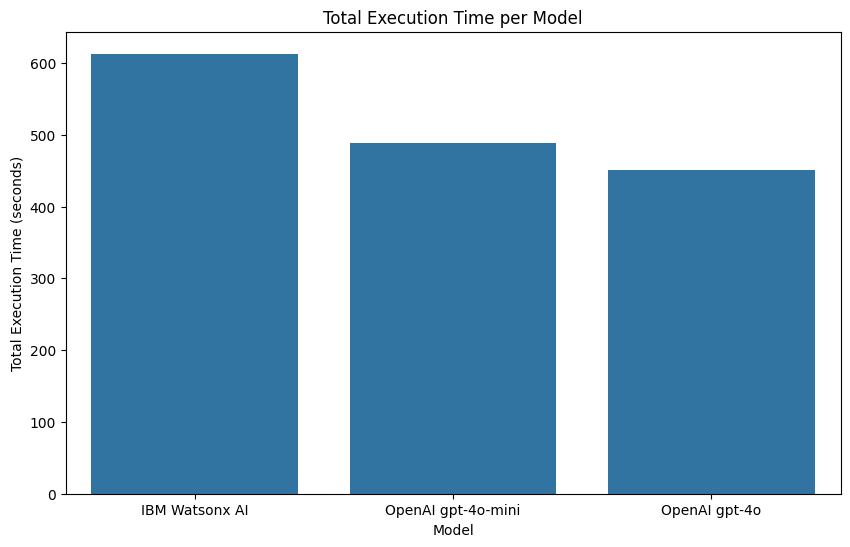

In [ ]:
# Se visualiza el tiempo total de ejecucion
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Total Execution Time (s)', data=comparison_df)
plt.title('Total Execution Time per Model')
plt.ylabel('Total Execution Time (seconds)')
plt.show()



Interpretación del tiempo total de ejecución:

Este gráfico de barras compara el tiempo total que tomó cada modelo para realizar las comparaciones de registros. Una barra más baja (gpt-4o) indica una ejecución general más rápida. Esto ayuda a identificar qué modelo fue el más eficiente en términos de tiempo de procesamiento para esta tarea específica.

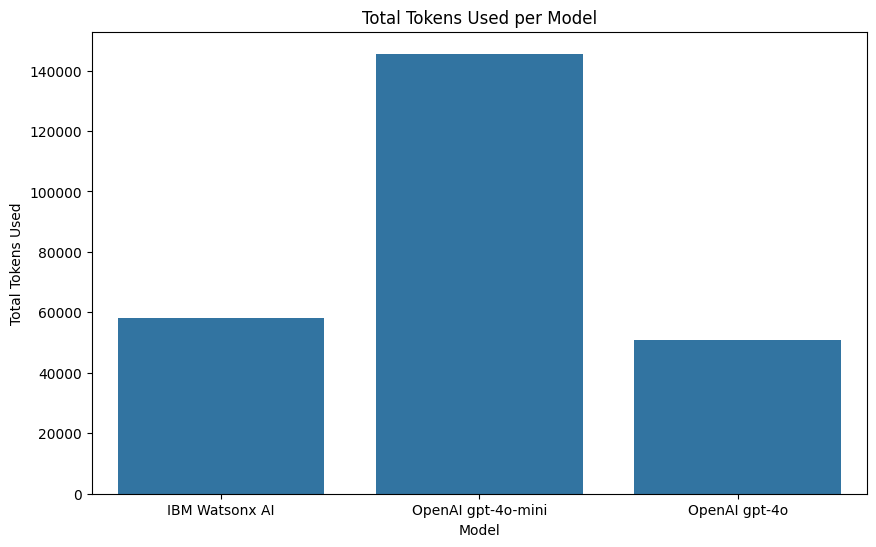

In [ ]:
# Se visualiza el total de Tokens usados
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Total Tokens Used', data=comparison_df)
plt.title('Total Tokens Used per Model')
plt.ylabel('Total Tokens Used')
plt.show()


Interpretación del total de tokens utilizados:

Este gráfico de barras muestra el número total de tokens consumidos por cada modelo durante el proceso de comparación. El uso de tokens es un factor clave en el costo de la API. Una barra más baja (gpt-4o) indica menor consumo de tokens, lo que generalmente se traduce en costos más bajos.

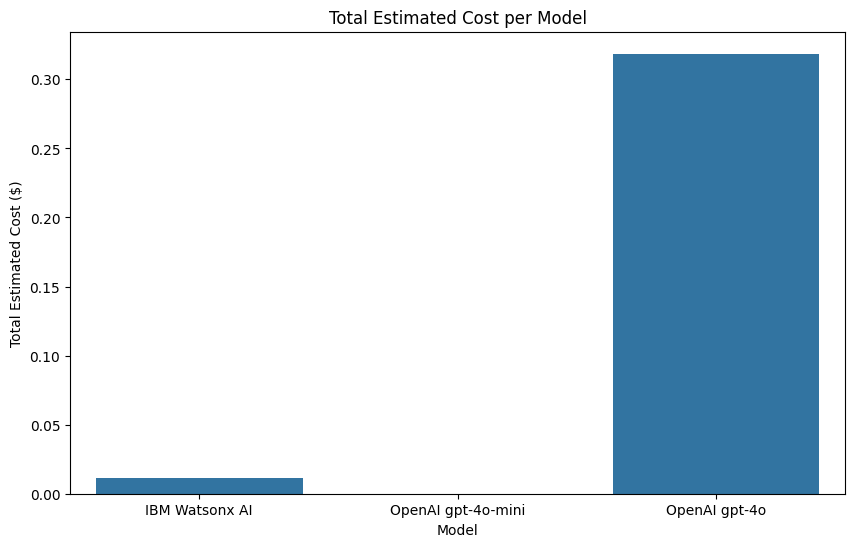

In [ ]:
# Se visualiza el costo total estimado
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Total Estimated Cost ($)', data=comparison_df)
plt.title('Total Estimated Cost per Model')
plt.ylabel('Total Estimated Cost ($)')
plt.show()


Interpretación del costo total estimado:

Este gráfico de barras compara directamente el costo total estimado de cada modelo, basado en el uso de tokens y la tarifa correspondiente. Esta visualización es crucial para comprender las implicaciones financieras de utilizar cada modelo para este tipo de tarea. Para el caso del modelo 4o-mini de OpenAI, el costo es tan pequeño comparado con el de gpt-4o que que practicamente no se ve.



## Conclusiones:

Basado en la comparación de las métricas totales de rendimiento:

	*	El modelo con el menor tiempo total de ejecución fue: OpenAI gpt-4o (450.92 segundos).
	*	El modelo con el menor costo total estimado fue: OpenAI gpt-4o-mini (USD 0.000022).
	*	El modelo que utilizó la menor cantidad total de tokens fue: OpenAI gpt-4o (50,911 tokens).

Aunque el modelo OpenAI gpt-4o presentó el menor tiempo total de ejecución y un alto desempeño en precisión, para nuestro caso particular el factor crítico es la eficiencia en el uso de tokens y el costo asociado. En este sentido, el modelo OpenAI gpt-4o-mini se destaca como la opción más adecuada, ya que combina un costo significativamente bajo con un nivel de resultados aceptable, ofreciendo un balance óptimo entre eficiencia económica y calidad de comparación de registros para la tarea planteada.